<a href="https://colab.research.google.com/github/Seb1456/Lab2-PTIA/blob/main/labNN_PTIA_c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-2
## REDES NEURONALES
## LABORATORIO 2/4

**NOMBRES:**
1. Sebastián Granados

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando redes neuronales
2. Implementar los algoritmos hacia adelante (FEED-FORWARD) y hacia atrás con  aprendizaje (BACKPROPAGATION)
3. Apropiar un framework para redes neuronales (*keras*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Esta tarea se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
***El entregable debe ser unicamente este archivo ".ipynb".*** Descargar como copia y cambiar la nomenclatura. No se permiten enlaces a colab

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “RN-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# PARTE I. IMPLEMENTACIÓN DE RED NEURONAL

Para este apartado se va a implementar una red neuronal con algoritmo de aprendizaje, en este caso propagación hacia atras del error.

*Introducido en la década de 1960 y popularizado casi 30 años después (1989) por Rumelhart, Hinton y Williams en el artículo titulado «Learning representations by back-propagating errors».*

## IMPLEMENTACIÓN DE RED NEURONAL CON PROPAGACIÓN HACIA ATRÁS

Implementar una red neuronal totalmente conectada desde su definición simple; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades y parámetros:**

*   Tarea: **Clasificación multiple**
*   Tipo de capas: **Densas**
*   Métrica para evaluación : **ACCURACY**

<div>
<img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b20d_644af5900694f1102fb9b470_classification_guide_apc05.png" width="350"/>
</div>

> **Funciones de activación**

*   Función de activación en *Capas ocultas* : **ReLU**

<div>
<img src="https://intuitivetutorial.com/wp-content/uploads/2023/07/ReLU-1.png" width="350"/>
</div>

*   Función de activación en *Capa de salida* : **Sigmoide**

<div>
<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2018/06/sigm.png" width="350"/>
</div>

> **Funcion de costo**

*   Función de costo/perdida «error»: **Entropia Cruzada «Cross-Entropy»**

<div>
<img src="https://framerusercontent.com/images/jiDTkbQC7DPO2z2XmxqoeMsrkA.webp?width=1300&height=508" width="450"/>
</div>







## Paso 1. Derivadas

*Incluya en este apartado el proceso de la derivación de las funciones*

---
**Derivada función Sigmoide:**

$$\sigma(z) = \frac{1}{1+e^{-z}} = (1+e^{-z})^{-1}$$

Aplicando la regla de la cadena:

$$\sigma'(z) = -(1+e^{-z})^{-2} \cdot (-e^{-z}) = \frac{e^{-z}}{(1+e^{-z})^2}$$

Separando la fracción:

$$\sigma'(z) = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}}$$

Como $\frac{e^{-z}}{1+e^{-z}} = \frac{(1+e^{-z}) - 1}{1+e^{-z}} = 1 - \frac{1}{1+e^{-z}} = 1 - \sigma(z)$:

$$\boxed{\sigma'(z) = \sigma(z)\,(1-\sigma(z))}$$


---
**Derivada función ReLU**

$$\text{ReLU}(z) = \max(0, z) = \begin{cases} z & z > 0 \\ 0 & z \leq 0 \end{cases}$$

Derivando cada tramo:

$$\frac{d}{dz}(z) = 1 \qquad \frac{d}{dz}(0) = 0$$

En $z = 0$ la derivada no está definida; por convención se toma 0:

$$\boxed{\text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}}$$


---
**Derivada función de costo: Entropia Cruzada**

Para $m$ ejemplos, con $y$ el valor esperado y $\hat{y}$ el predicho:

$$E = -\frac{1}{m}\sum_{i=1}^{m}\left[\,y_i \ln(\hat{y}_i) + (1-y_i)\ln(1-\hat{y}_i)\,\right]$$

Derivando respecto a $\hat{y}$ (elemento por elemento), con $\frac{d}{dx}\ln(x) = \frac{1}{x}$ y $\frac{d}{dx}\ln(1-x) = -\frac{1}{1-x}$:

$$\frac{\partial E}{\partial \hat{y}} = -\left[\frac{y}{\hat{y}} - \frac{1-y}{1-\hat{y}}\right]$$

Llevando a común denominador:

$$\frac{\partial E}{\partial \hat{y}} = -\frac{y(1-\hat{y}) - \hat{y}(1-y)}{\hat{y}(1-\hat{y})} = -\frac{y - \hat{y}}{\hat{y}(1-\hat{y})}$$

$$\boxed{\frac{\partial E}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1-\hat{y})}}$$

**Combinada con la sigmoide** (capa de salida, $\hat{y} = \sigma(z)$), por regla de la cadena:

$$\frac{\partial E}{\partial z} = \frac{\partial E}{\partial \hat{y}} \cdot \sigma'(z) = \frac{\hat{y} - y}{\hat{y}(1-\hat{y})} \cdot \hat{y}(1-\hat{y})$$

$$\boxed{\frac{\partial E}{\partial z} = \hat{y} - y}$$


## Paso 2. Implementación del código para ANN (Dense)

### LIBRERÍA NECESARIA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

### FUNCIONES DE BASE: MÉTRICA, COSTO Y ACTIVACIÓN

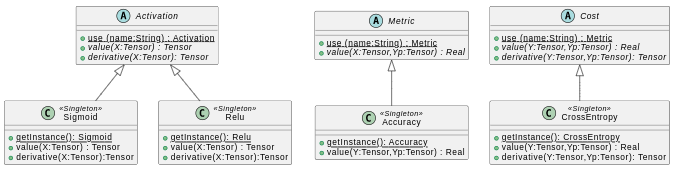

###MÉTRICA

In [2]:
class Metric(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier metrica
  Representa la metrica de una red neuronal
  """
  @staticmethod
  def use(name: str) -> "Métrica":
    """ obtiene metrica (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la metrica
    Returns:
      self (Metric): objeto metrica
    """
    metrics = {"accuracy": Accuracy};
    return metrics[name.lower()]()

  def value(self, Y: np.ndarray, Yp:np.ndarray):
    """ computa el desempeño (accuracy) de la red (> 0.6 es 1)
    Args:
      Y (ndarray): valores de salidas esperadas (etiquetadas)
      Yp (ndarray): valores de salidas obtenidas
    Return:
      A (float): valor del desempeño
    """
    pass

In [3]:
# Documentar los métodos implementados
class Accuracy(Metric):
  """ Metrica de exactitud (acertados / totales). Implementa Metric
  """
  def __init__(self, threshold: float = 0.6):
    self.threshold = threshold

  def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
    """ Una salida: Yp > umbral es 1. Varias salidas: la clase es la de mayor valor (argmax) """
    if Y.shape[0] == 1:
      pred = (Yp > self.threshold).astype(int)
      return float(np.mean(pred == Y))
    return float(np.mean(np.argmax(Yp, axis=0) == np.argmax(Y, axis=0)))

In [4]:
# Adicione los casos de prueba de los métodos implementados
# Casos de Prueba Accuracy
acc = Metric.use("accuracy")

Y = np.array([[1,0,1,1]])
Yp = np.array([[0.9, 0.2,0.4,0.7]])
assert np.isclose(acc.value(Y, Yp), 0.75)

Y = np.array([[1, 0], [0, 0], [0, 1]])
Yp = np.array([[0.7, 0.1], [0.2, 0.3], [0.1, 0.8]])
assert np.isclose(acc.value(Y, Yp), 1.0)

print("Accuracy con pruebas completas.")

Accuracy con pruebas completas.


###COSTO

In [5]:
class Cost(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier función de costo
  Representa la función de costo o error de una red neuronal
  """
  @staticmethod
  def use(name: str) -> "Costo":
    """ obtiene función de costo (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la función
    Returns:
      self (Cost): objeto función de costo
    """
    costs = {"cross-entropy": CrossEntropy, "crossentropy": CrossEntropy};
    return costs[name.lower()]()

  def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
    """ computa la función de costo
    Args:
      Y (ndarray): valores de salida obtenidos
      Yp (ndarray): valores de salida esperados
    Returns:
      S (float): valor de computo de la función de costo
    """
    pass

  def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de costo (gradiente) <elemento por elemento>
    Args:
      Y (ndarray): valores de salida obtenidos
      Yp (ndarray): valores de salida esperados
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de costo
    """
    pass

In [6]:
# Documentar los métodos implementados
class CrossEntropy(Cost):
  """ Función de costo Entropia Cruzada. Implementa Cost
  """
  def __init__(self, epsilon: float = 1e-12):
    self.epsilon = epsilon  # evita log(0) y divisiones por 0

  def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
    """ E = -1/m * sum(y*ln(yp) + (1-y)*ln(1-yp)) """
    m = Y.shape[1]
    Yp = np.clip(Yp, self.epsilon, 1 - self.epsilon)
    return -np.sum(Y * np.log(Yp) + (1 - Y) * np.log(1 - Yp)) / m

  def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    """ dE/dyp = (yp - y) / (yp*(1-yp)) """
    Yp = np.clip(Yp, self.epsilon, 1 - self.epsilon)
    return (Yp - Y) / (Yp * (1 - Yp))

In [7]:
# Adicione los casos de prueba de los métodos implementados
# Casos de Prueba CrossEntropy
ce = Cost.use("cross-entropy")
Y = np.array([[1, 0]])
Yp = np.array([[0.9, 0.1]])

assert np.isclose(ce.value(Y, Yp), -np.log(0.9))
assert ce.value(Y, np.array([[1.0, 0.0]])) < 1e-9
assert np.allclose(ce.derivative(Y, Yp), [[-1/0.9, 1/0.9]])

print("CrossEntropy con pruebas completas.")

CrossEntropy con pruebas completas.


###ACTIVACION

In [8]:
class Activation(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave de cualquier función de activación
  Representa la función de activación de cualquier neurona en la red neuronal
  """
  @staticmethod
  def use(name: str) -> "Activación":
    """ obtiene función de activación (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la función
    Returns:
      self (Activation): objeto función de activación
    """
    activations = {"sigmoid": Sigmoid, "relu": Relu};
    return activations[name.lower()]()

  def value(self, X: np.ndarray) -> np.ndarray:
    """ computa la función de activación <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      S (ndarray): valores de computo de la función de activación
    """
    pass

  def derivative(self, X: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de activación (gradiente) <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de activación
    """
    pass

In [9]:
# Documentar los métodos implementados
class Sigmoid(Activation):
  """ Función de activación sigmoide. Implementa Activación
  """
  def value(self, X: np.ndarray) -> np.ndarray:
    """ 1 / (1 + e^-x); se recorta x para evitar overflow """
    return 1 / (1 + np.exp(-np.clip(X, -500, 500)))

  def derivative(self, X: np.ndarray) -> np.ndarray:
    """ s(x) * (1 - s(x)) """
    s = self.value(X)
    return s * (1 - s)

In [10]:
# Documentar los métodos implementados
class Relu(Activation):
  """ Función de activación RELU. Implementa Activación
  """
  def value(self, X: np.ndarray) -> np.ndarray:
    """ max(0, x) """
    return np.maximum(0, X)

  def derivative(self, X: np.ndarray) -> np.ndarray:
    """ 1 si x > 0, si no 0 """
    return (X > 0).astype(float)

In [11]:
# Adicione los casos de prueba de los métodos implementados
# Casos de prueba: Sigmoid y Relu
sig  = Activation.use("sigmoid")
relu = Activation.use("relu")

# Sigmoide: σ(0) = 0.5, σ'(0) = 0.25
assert np.isclose(sig.value(np.array([0.0])), 0.5)
assert np.isclose(sig.derivative(np.array([0.0])), 0.25)
assert np.allclose(sig.value(np.array([1000.0, -1000.0])), [1.0, 0.0])

# Verificación numérica de la derivada (diferencias finitas)
z, h = np.array([-2.0, 0.5, 3.0]), 1e-6
numerica = (sig.value(z + h) - sig.value(z - h)) / (2 * h)
assert np.allclose(sig.derivative(z), numerica)

# ReLU
x = np.array([-2.0, 0.0, 3.0])
assert np.array_equal(relu.value(x), [0.0, 0.0, 3.0])
assert np.array_equal(relu.derivative(x), [0.0, 0.0, 1.0])

print("Activaciones: pruebas superadas")


Activaciones: pruebas superadas


## RED NEURONAL TOTALMENTE CONECTADA «DENSE»

####Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (c) o todos los ejemplos (cxm)
  - **y**, **Y** : salidas reales. Un ejemplo (cx1) o todos los ejemplos(cxm)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (cx1) o todos los ejemplos(cxm)
* **Arquitectura**
  - *L*: número de capas
  - **layers**: **n**[*0*] = c, **layers**[*i*] número de neuronas de la capa *i*
* **Parámetros**
  - **W**: pesos de una capa (**layers**[*l+1*]x**layers**[*l*])
  - **b**: sesgos de una capa (**n**[*l* ]x1)

* **Gradientes**
  - **dW**: gradiente de **W**
  - **db**: gradiente de **b**

*Incluya en este apartado el proceso de la derivación de los gradientes*

---
**Gradiente dW**

Para cada capa $l$, el forward es:

$$Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]} \qquad A^{[l]} = g(Z^{[l]})$$

Por regla de la cadena, primero el error respecto a $Z$:

$$dZ^{[l]} = \frac{\partial E}{\partial Z^{[l]}} = dA^{[l]} \odot g'(Z^{[l]})$$

Como $\frac{\partial Z^{[l]}}{\partial W^{[l]}} = A^{[l-1]}$, promediando sobre los $m$ ejemplos:

$$\boxed{dW^{[l]} = \frac{1}{m}\, dZ^{[l]} \left(A^{[l-1]}\right)^T}$$

En la capa de salida (sigmoide + entropía cruzada), por el Paso 1:

$$dZ^{[L]} = \hat{Y} - Y$$

Para propagar el error a la capa anterior:

$$dA^{[l-1]} = \left(W^{[l]}\right)^T dZ^{[l]}$$


---
**Graciente db**

Como $\frac{\partial Z^{[l]}}{\partial b^{[l]}} = 1$, el gradiente es $dZ^{[l]}$ sumado sobre los $m$ ejemplos:

$$\boxed{db^{[l]} = \frac{1}{m} \sum_{i=1}^{m} dZ^{[l](i)}}$$

**Actualización (descenso de gradiente)** con tasa de aprendizaje $\eta$:

$$W^{[l]} = W^{[l]} - \eta\, dW^{[l]} \qquad b^{[l]} = b^{[l]} - \eta\, db^{[l]}$$



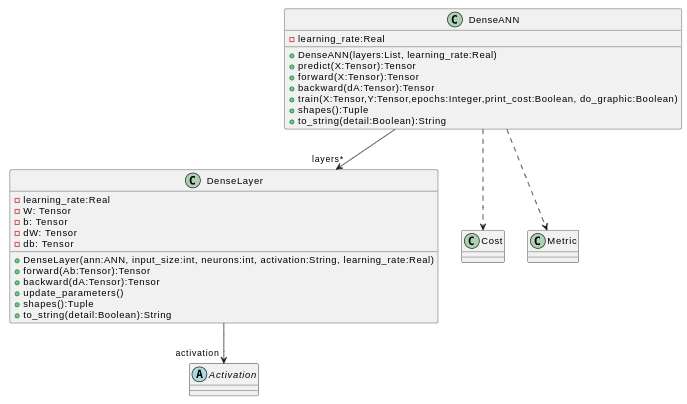

In [12]:
class DenseANN:
  """ Representa una red neuronal totalmente conectada
  """
  def __init__(self, layers: list, learning_rate: float):
    """ inicializar las capas, luego almacenar la arquitectura de la red y la tasa de aprendizaje.
    Args:
      layers (list): número de -> caracteristicas de entrada (list[0]), neuronas en la capa oculta i, neuronas de salida (list[-1])
      learning_rate (float): eta tasa de aprendizaje de la red
    """
    self.learning_rate = learning_rate
    self.cost = Cost.use("cross-entropy")
    self.metric = Metric.use("accuracy")
    self.layers = []
    for i in range(1, len(layers)):
      activation = "sigmoid" if i == len(layers) - 1 else "relu"
      self.layers.append(DenseLayer(layers[i-1], layers[i], activation, learning_rate))

  def predict(self, X: np.ndarray):
    """ computa valores de predicción a partir de las entradas
    Args:
      X (ndarray): valores de características (entradas)
    Return:
      Yp (ndarray): valores de salidas obtenidas
    """
    return self.forward(X)

  def forward(self, X: np.ndarray):
    """ computa hacia adelante un ciclo de entradas a traves de la red generando una predicción
    Args:
      X (ndarray): valores de características (entradas)
    Return:
      Yp (ndarray): valores de salidas obtenidas
    """
    A = X
    for layer in self.layers:
      A = layer.forward(A)
    return A

  def backward(self, dA: np.ndarray):
    """ computa hacia atras los errores y gradientes
    Args:
      dA (ndarray): valores del gradiente de predicción
    Return:
      G (ndarray): gradientes de la red
    """
    for layer in reversed(self.layers):
      dA = layer.backward(dA)
    return [(layer.dW, layer.db) for layer in self.layers]

  def train(self, X: np.ndarray, Y: np.ndarray, epochs: int, print_cost: bool = False, do_graphic: bool = False):
    """ entrenar red neuronal
    Args:
      X (ndarray): valores de características - conjunto de entrenamiento
      Y (ndarray): valores de salidas esperadas - conjunto de entrenamiento
      epochs (int): número de iteraciones
      print_cost (bool): mostrar el costo por iteración
      do_graphic (bool): graficar el costo por iteración
    """
    costs = []
    for i in range(epochs):
      Yp = self.forward(X)
      costs.append(self.cost.value(Y, Yp))
      self.backward(self.cost.derivative(Y, Yp))
      for layer in self.layers:
        layer.update_parameters()
      if print_cost and i % max(1, epochs // 10) == 0:
        print(f"Época {i}: costo = {costs[-1]:.4f}  accuracy = {self.metric.value(Y, Yp):.2f}")
    if do_graphic:
      plt.plot(costs)
      plt.xlabel("Época")
      plt.ylabel("Costo")
      plt.title("Costo por época")
      plt.show()
    return costs

  def shapes(self):
    """ genera los valores asociados al tamaño de la red
    Return:
      s (tupla<int>): tamaño de la red
    """
    return tuple(layer.shapes() for layer in self.layers)

  def to_string(self, detail: bool = False):
    """ texto con la arquitectura de la red
    """
    return "\n".join(layer.to_string(detail) for layer in self.layers)

## CAPA CON PERCEPTRONES

In [13]:
class DenseLayer:
  """ Representa una capa (oculta o salida) en la red neuronal
  """
  def __init__(self, input_size: int, neurons: int, activation: str, learning_rate: float):
    """ inicializar una capa de neuronas dentro de la red neuronal.
    Args:
      input_size (int): número de neuronas de capa anterior o de atributos de entrada
      neurons (int): número de neuronas en la capa
      activation (str): nombre de la función de activación
      learning_rate (float): eta tasa de aprendizaje de la red
    """
    self.learning_rate = learning_rate
    self.activation = Activation.use(activation)
    self.W = np.random.randn(neurons, input_size) * np.sqrt(2 / input_size)
    self.b = np.zeros((neurons, 1))
    self.dW = np.zeros_like(self.W)
    self.db = np.zeros_like(self.b)

  def forward(self, Ab: np.ndarray):
    """ Transmite la entrada a partir del acumulativo de señales (f_base) y el potencial eléctrico (f_activación).
    Args:
      Ab (np.ndarray): características ó valores de activación de la capa anterior
    Return:
      S (np.ndarray): valores de activación de neuronas
    """
    self.Ab = Ab
    self.Z = self.W @ Ab + self.b
    return self.activation.value(self.Z)

  def backward(self, dA: np.ndarray):
    """ Transmite hacia atras el cambio del grandiente y el error (delta)
    Args:
      dA (np.ndarray): gradiente del error respecto a la salida de esta capa
    Return:
      S (np.ndarray): gradiente del error para la capa anterior
    """
    m = dA.shape[1]
    dZ = dA * self.activation.derivative(self.Z)
    self.dW = dZ @ self.Ab.T / m
    self.db = np.sum(dZ, axis=1, keepdims=True) / m
    return self.W.T @ dZ

  def update_parameters(self):
    """ Actualiza los parámetros de la capa a partir del gradiente y el error.
    """
    self.W -= self.learning_rate * self.dW
    self.b -= self.learning_rate * self.db

  def shapes(self):
    """ genera los valores asociados al tamaño de la capa
    Return:
      s (tupla<int>): tamaño de la capa
    """
    return self.W.shape, self.b.shape

  def to_string(self, detail: bool = False):
    """ texto con el tamaño y activación de la capa (y sus pesos si detail)
    """
    s = f"Dense: {self.W.shape[1]} -> {self.W.shape[0]} ({type(self.activation).__name__})"
    if detail:
      s += f"\n  W = {np.round(self.W, 3).tolist()}\n  b = {np.round(self.b.ravel(), 3).tolist()}"
    return s

## CASOS DE PRUEBA

Época 0: costo = 0.9093  accuracy = 0.75
Época 200: costo = 0.1347  accuracy = 1.00
Época 400: costo = 0.0786  accuracy = 1.00
Época 600: costo = 0.0550  accuracy = 1.00
Época 800: costo = 0.0422  accuracy = 1.00
Época 1000: costo = 0.0341  accuracy = 1.00
Época 1200: costo = 0.0286  accuracy = 1.00
Época 1400: costo = 0.0246  accuracy = 1.00
Época 1600: costo = 0.0216  accuracy = 1.00
Época 1800: costo = 0.0192  accuracy = 1.00


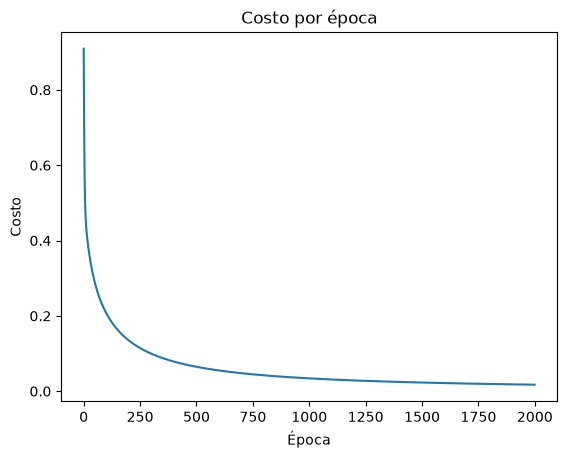

Predicción: [[0.    0.02  0.02  0.972]]
Accuracy: 1.0
Dense: 2 -> 1 (Sigmoid)
  W = [[7.429, 7.429]]
  b = [-11.317]


In [14]:
# Como primer caso de prueba entrene un perceptrón para calcular el operador lógico and. Explique los resultados.
np.random.seed(0)
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])
Y_and = np.array([[0, 0, 0, 1]])

ann_and = DenseANN([2, 1], learning_rate=0.5)
ann_and.train(X, Y_and, epochs=2000, print_cost=True, do_graphic=True)

Yp = ann_and.predict(X)
print("Predicción:", np.round(Yp, 3))
print("Accuracy:", ann_and.metric.value(Y_and, Yp))
print(ann_and.to_string(detail=True))

**Resultados AND:** el perceptrón aprende AND (accuracy 1.0). AND es linealmente separable: una recta separa (1,1) del resto.

Época 0: costo = 0.3682  accuracy = 0.75
Época 200: costo = 0.0814  accuracy = 1.00
Época 400: costo = 0.0445  accuracy = 1.00
Época 600: costo = 0.0303  accuracy = 1.00
Época 800: costo = 0.0229  accuracy = 1.00
Época 1000: costo = 0.0184  accuracy = 1.00
Época 1200: costo = 0.0153  accuracy = 1.00
Época 1400: costo = 0.0131  accuracy = 1.00
Época 1600: costo = 0.0115  accuracy = 1.00
Época 1800: costo = 0.0102  accuracy = 1.00


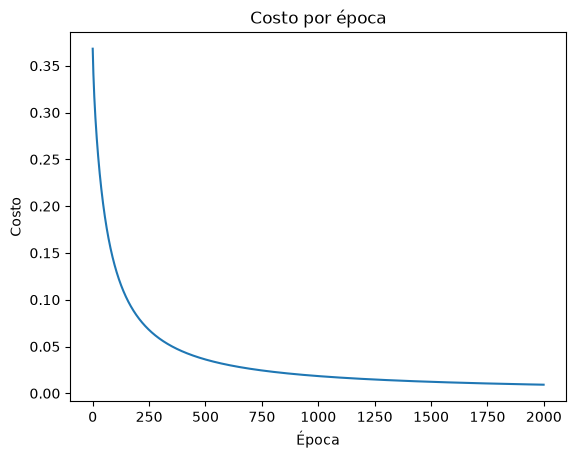

Predicción: [[0.02  0.992 0.992 1.   ]]
Accuracy: 1.0
Dense: 2 -> 1 (Sigmoid)
  W = [[8.686, 8.685]]
  b = [-3.878]


In [15]:
# Como segundo caso de prueba entrene un perceptrón para calcular el operador lógico or. Explique los resultados.
np.random.seed(0)
Y_or = np.array([[0, 1, 1, 1]])

ann_or = DenseANN([2, 1], learning_rate=0.5)
ann_or.train(X, Y_or, epochs=2000, print_cost=True, do_graphic=True)

Yp = ann_or.predict(X)
print("Predicción:", np.round(Yp, 3))
print("Accuracy:", ann_or.metric.value(Y_or, Yp))
print(ann_or.to_string(detail=True))

**Resultados OR:** el perceptrón aprende OR (accuracy 1.0). También es linealmente separable.

Época 0: costo = 0.9093  accuracy = 0.50
Época 200: costo = 0.6932  accuracy = 0.50


Época 400: costo = 0.6931  accuracy = 0.50
Época 600: costo = 0.6931  accuracy = 0.50
Época 800: costo = 0.6931  accuracy = 0.50
Época 1000: costo = 0.6931  accuracy = 0.50
Época 1200: costo = 0.6931  accuracy = 0.50
Época 1400: costo = 0.6931  accuracy = 0.50
Época 1600: costo = 0.6931  accuracy = 0.50
Época 1800: costo = 0.6931  accuracy = 0.50


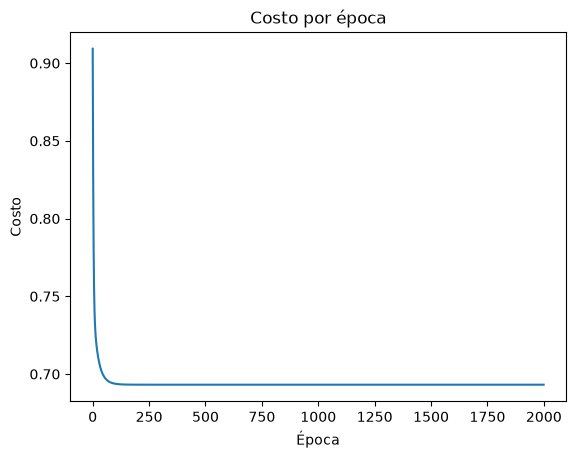

Predicción: [[0.5 0.5 0.5 0.5]]
Accuracy: 0.5


In [16]:
# Como tercer caso de prueba entrene un perceptrón para calcular el operador lógico xor. Explique los resultados.
np.random.seed(0)
Y_xor = np.array([[0, 1, 1, 0]])

ann_xor = DenseANN([2, 1], learning_rate=0.5)
ann_xor.train(X, Y_xor, epochs=2000, print_cost=True, do_graphic=True)

Yp = ann_xor.predict(X)
print("Predicción:", np.round(Yp, 3))
print("Accuracy:", ann_xor.metric.value(Y_xor, Yp))

**Resultados XOR:** el perceptrón no aprende XOR (accuracy 0.5, predice 0.5 para todo). XOR no es linealmente separable y un perceptrón solo traza una recta.

Época 0: costo = 0.9195  accuracy = 0.50


Época 500: costo = 0.0106  accuracy = 1.00
Época 1000: costo = 0.0045  accuracy = 1.00


Época 1500: costo = 0.0028  accuracy = 1.00
Época 2000: costo = 0.0020  accuracy = 1.00
Época 2500: costo = 0.0016  accuracy = 1.00


Época 3000: costo = 0.0013  accuracy = 1.00


Época 3500: costo = 0.0011  accuracy = 1.00
Época 4000: costo = 0.0009  accuracy = 1.00
Época 4500: costo = 0.0008  accuracy = 1.00


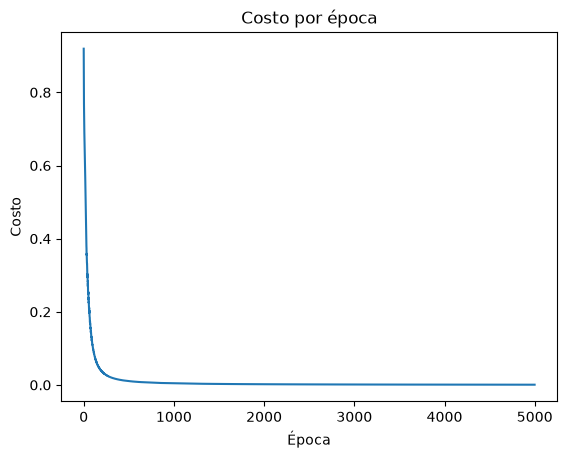

Predicción: [[0.002 1.    1.    0.   ]]
Accuracy: 1.0
Dense: 2 -> 2 (Relu)
  W = [[3.184, 3.184], [4.337, 4.337]]
  b = [-0.0, -4.338]
Dense: 2 -> 1 (Sigmoid)
  W = [[4.493, -7.128]]
  b = [-6.174]


In [17]:
# Como cuarto caso de prueba entrene un perceptrón multicapa [2,2,1] para calcular el operador lógico xor. Explique los resultados
np.random.seed(0)
ann_xor2 = DenseANN([2, 2, 1], learning_rate=0.5)
ann_xor2.train(X, Y_xor, epochs=5000, print_cost=True, do_graphic=True)

Yp = ann_xor2.predict(X)
print("Predicción:", np.round(Yp, 3))
print("Accuracy:", ann_xor2.metric.value(Y_xor, Yp))
print(ann_xor2.to_string(detail=True))

**Resultados XOR multicapa [2,2,1]:** con una capa oculta la red sí aprende XOR (accuracy 1.0), porque la capa oculta transforma los datos en un espacio donde sí son separables. Depende de la inicialización (algunas ReLU pueden quedar en 0), por eso se fija la semilla.

Datos: (1484, 8)  Etiquetas: ['CYT', 'ERL', 'EXC', 'ME1', 'ME2', 'ME3', 'MIT', 'NUC', 'POX', 'VAC']
Época 0: costo = 7.8059  accuracy = 0.03


Época 300: costo = 1.6477  accuracy = 0.63


Época 600: costo = 1.6186  accuracy = 0.65


Época 900: costo = 1.6029  accuracy = 0.65


Época 1200: costo = 1.5867  accuracy = 0.65


Época 1500: costo = 1.5746  accuracy = 0.65


Época 1800: costo = 1.5696  accuracy = 0.65


Época 2100: costo = 1.5657  accuracy = 0.65


Época 2400: costo = 1.5600  accuracy = 0.66


Época 2700: costo = 1.5568  accuracy = 0.66


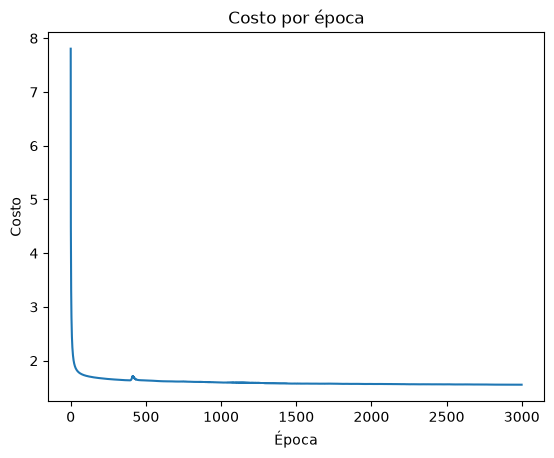

Dense: 8 -> 16 (Relu)
Dense: 16 -> 10 (Sigmoid)
Accuracy entrenamiento: 0.6537
Accuracy pruebas: 0.5825
Hamming accuracy pruebas: 0.9195


In [18]:
# Como último caso de prueba entrene una red para el dataset propuesto por su profesor. Use 80% para entrenamiento y 20% para pruebas. Explique los resultado.
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Yeast (UCI): se usa el archivo local si existe, si no se descarga
ruta = "yeast.data" if os.path.exists("yeast.data") else "https://archive.ics.uci.edu/ml/machine-learning-databases/yeast/yeast.data"
columnas = ["sequence", "mcg", "gvh", "alm", "mit", "erl", "pox", "vac", "nuc", "localizacion"]
yeast = pd.read_csv(ruta, sep=r"\s+", header=None, names=columnas)

Xy = yeast.drop(columns=["sequence", "localizacion"]).values
Yy = pd.get_dummies(yeast["localizacion"]).astype(float)  # una columna binaria por localización
etiquetas = list(Yy.columns)
print("Datos:", Xy.shape, " Etiquetas:", etiquetas)

Xy_train, Xy_test, Yy_train, Yy_test = train_test_split(Xy, Yy.values, test_size=0.2, stratify=yeast["localizacion"], random_state=42)

scaler = StandardScaler()
Xy_train = scaler.fit_transform(Xy_train)
Xy_test = scaler.transform(Xy_test)

# La red trabaja con (características x ejemplos) y (etiquetas x ejemplos)
Xy_train, Xy_test = Xy_train.T, Xy_test.T
Yy_train, Yy_test = Yy_train.T, Yy_test.T

np.random.seed(0)
ann_yeast = DenseANN([8, 16, 10], learning_rate=0.5)
ann_yeast.train(Xy_train, Yy_train, epochs=3000, print_cost=True, do_graphic=True)

Yp_train = ann_yeast.predict(Xy_train)
Yp_test = ann_yeast.predict(Xy_test)
print(ann_yeast.to_string())
print("Accuracy entrenamiento:", round(ann_yeast.metric.value(Yy_train, Yp_train), 4))
print("Accuracy pruebas:", round(ann_yeast.metric.value(Yy_test, Yp_test), 4))
# Exactitud por etiqueta (cada salida > 0.6 se toma como 1)
print("Hamming accuracy pruebas:", round(np.mean((Yp_test > 0.6) == Yy_test), 4))

**Resultados Yeast (multietiqueta):** cada localización es una salida sigmoide independiente, así una proteína puede tener varias etiquetas.

* Accuracy ≈ 65% en entrenamiento y ≈ 58% en pruebas; no hay sobreajuste fuerte.
* Exactitud por etiqueta (Hamming) ≈ 92%.
* El resultado es moderado porque las clases están desbalanceadas y algunas localizaciones (CYT y NUC) tienen características muy parecidas.

# PARTE 2. USO DE FRAMEWORK PARA REDES NEURONALES

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintas redes neuronales. En este caso será **Keras**

> Keras proporciona una interfaz Python simplificada para TensorFlow y se ha convertido en uno de los framework más usados en redes neuronales; especialmente las profundas. Cualquier código Keras que escribas se ejecuta en en TensorFlow (también se pueden utilizar CNTK y Theano como *back-end*, pero el desarrollo de estos se ha detenido).

Keras ofrece dos API: una [API secuencial](https://keras.io/guides/sequential_model/) y una [API funcional](https://keras.io/guides/functional_api/). La primera es más sencilla y resulta suficiente para la mayoría de las redes neuronales. La segunda es útil en escenarios  como redes con topologías no secuenciales o de capas compartidas. En nuestro caso usaremos el API secuencial.

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

In [19]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import set_random_seed

set_random_seed(42)

# Wine (UCI): se usa el archivo local si existe, si no se descarga
ruta = "wine.data" if os.path.exists("wine.data") else "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"
columnas = ["clase", "alcohol", "malic_acid", "ash", "alcalinity_of_ash", "magnesium", "total_phenols",
            "flavanoids", "nonflavanoid_phenols", "proanthocyanins", "color_intensity", "hue",
            "od280_od315", "proline"]
df = pd.read_csv(ruta, header=None, names=columnas)
df.head()

,clase,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


##Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adeucada y establecer un umbral de desempeño.


**Problema:** predecir a cuál de los 3 cultivares pertenece un vino a partir de 13 características químicas. Es clasificación multiclase.

**Métrica:** accuracy, porque las clases están casi balanceadas.

**Umbral:** accuracy ≥ 90% en pruebas.

##Paso 2: Explorar y preparar los datos
Para comprender la neturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, entre otras cosas, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).

(178, 14)
Nulos por columna:
 clase                   0
alcohol                 0
malic_acid              0
ash                     0
alcalinity_of_ash       0
magnesium               0
total_phenols           0
flavanoids              0
nonflavanoid_phenols    0
proanthocyanins         0
color_intensity         0
hue                     0
od280_od315             0
proline                 0
dtype: int64
                      count        mean         std     min       25%  \
clase                 178.0    1.938202    0.775035    1.00    1.0000   
alcohol               178.0   13.000618    0.811827   11.03   12.3625   
malic_acid            178.0    2.336348    1.117146    0.74    1.6025   
ash                   178.0    2.366517    0.274344    1.36    2.2100   
alcalinity_of_ash     178.0   19.494944    3.339564   10.60   17.2000   
magnesium             178.0   99.741573   14.282484   70.00   88.0000   
total_phenols         178.0    2.295112    0.625851    0.98    1.7425   
flavanoid

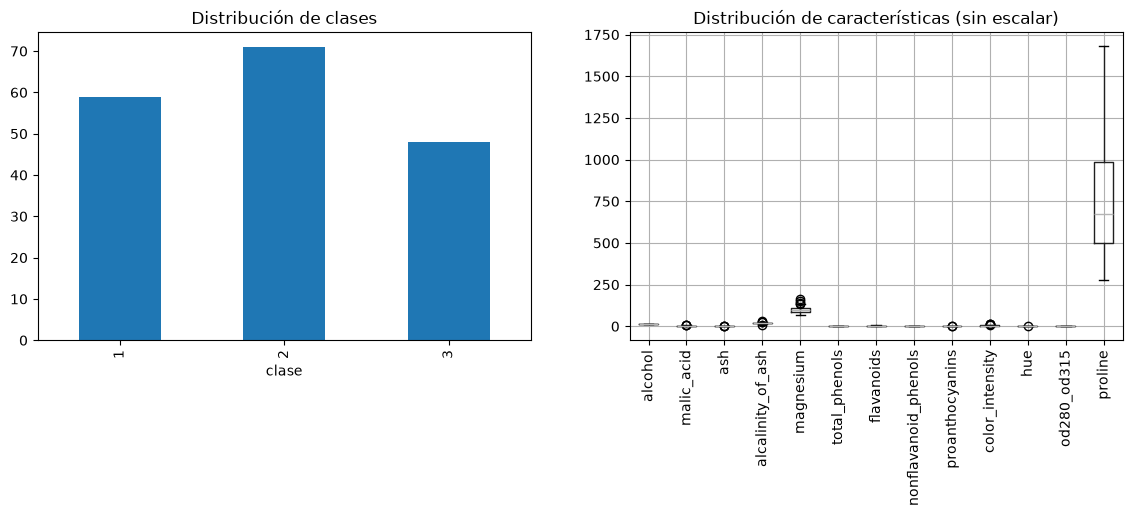

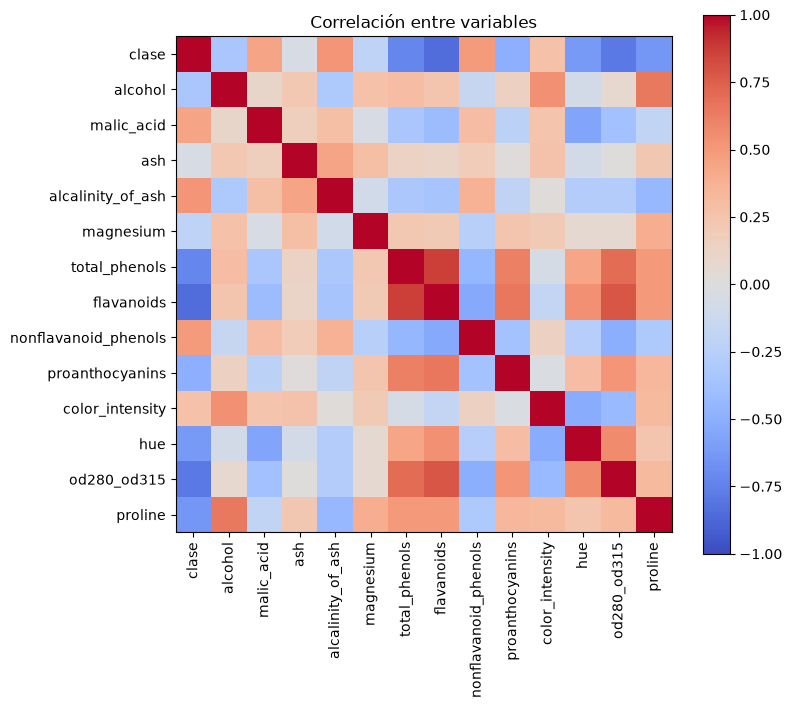

In [20]:
#Analizar los datos
print(df.shape)
print("Nulos por columna:\n", df.isnull().sum())
print(df.describe().T)

conteo = df["clase"].value_counts().sort_index()
print(conteo)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
conteo.plot(kind="bar", ax=axes[0], title="Distribución de clases")
df.drop(columns=["clase"]).boxplot(ax=axes[1], rot=90)
axes[1].set_title("Distribución de características (sin escalar)")
plt.show()

corr = df.corr()
plt.figure(figsize=(8, 7))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.title("Correlación entre variables")
plt.show()

**Observaciones**

* 178 ejemplos, 13 características, sin valores nulos.
* Clases casi balanceadas (59 / 71 / 48).
* Las escalas son muy distintas (`proline` > 1000, `hue` < 2), por eso se estandariza.
* `flavanoids`, `total_phenols` y `od280_od315` están muy relacionadas con la clase.

In [21]:
#Preparar los datos separandolos en entrenamiento, validación y pruebas.
X = df.drop(columns=["clase"]).values
y = df["clase"].values - 1  # clases 1,2,3 -> 0,1,2

# 20% pruebas, y del 80% restante 1/8 para validación -> 70% / 10% / 20%
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Entrenamiento:", X_train.shape, " Validación:", X_val.shape, " Pruebas:", X_test.shape)

Entrenamiento: (124, 13)  Validación: (18, 13)  Pruebas: (36, 13)


##Paso 3: Desarrollar la red

### Paso 3.1: Definir el modelo Keras

Crear una red neuronal utilizando la API secuencial de Keras es sencillo.

1. Se crea una instancia de la clase Sequential.
2. Se llama a *add* en el objeto *Sequential* para añadir capas. Las capas en sí mismas son instancias de clases como Dense, que representa una capa totalmente conectada con un número específico de neuronas que utilizan una función de activación específica.

In [22]:
# Inicializar modelo Sequencial()
# Añadir capas de la clase Dense: .add(Dense(...))
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(16, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(3, activation="softmax"))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

### Paso 3.2: Compilar el modelo Keras

Una vez inicializado el modelo, hay que compilarlo. Para esto hay que definir las propiedades adicionales necesarias para entrenar la red.

Se debe especificar minimamente:
1. la **función de pérdida** que se utilizará para evaluar un conjunto de pesos
2. el **optimizador** utilizado para buscar diferentes pesos para la red, que en la versión clásica se usa el *gradiente descendente*, pero existen otros famosos como *ADAM*
3. la **métrica** que se desea reportar durante el entrenamiento.

In [23]:
#Compilar el modelo
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

### Paso 3.3: Entrenar (Fit) el modelo Keras

Una vez compilado, es el momento de entrenar o ajustar el modelo con algunos datos. Para esto se hace llamando al método ***fit()*** del modelo.

Tenga en cuenta que el entrenamiento se realiza por épocas (*epoch*), y cada época se divide en lotes (*batch*).

1. **Epoch:** un ciclo/pasada por todas las observaciones del conjunto de datos de entrenamiento.
2. **Batch:** un ciclo de una o más observaciones en un *epoch* antes de que se actualicen los pesos.

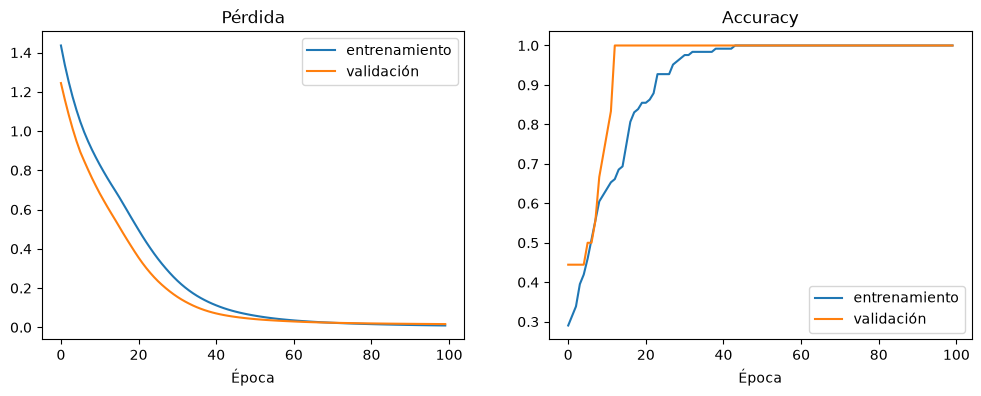

In [24]:
#Entrenar el modelo
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=16, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="entrenamiento")
axes[0].plot(history.history["val_loss"], label="validación")
axes[0].set_title("Pérdida")
axes[1].plot(history.history["accuracy"], label="entrenamiento")
axes[1].plot(history.history["val_accuracy"], label="validación")
axes[1].set_title("Accuracy")
for ax in axes:
  ax.set_xlabel("Época")
  ax.legend()
plt.show()

### Paso 3.4: Evaluar el modelo Keras

Ya entrenada la red neuronal con todo el conjunto de datos de entrenamiento, se puede evaluar su rendimiento con otra serie de datos.

Para evaluar el modelo se puede hacer uso del método ***evaluate()*** agregandole los respectivos conjuntos de datos con su la salida esperada.

In [25]:
#Evaluar el modelo
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Pérdida en pruebas: {loss:.4f}")
print(f"Accuracy en pruebas: {acc:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Clase 1", "Clase 2", "Clase 3"]))

Pérdida en pruebas: 0.2030
Accuracy en pruebas: 0.9444


Matriz de confusión:
 [[12  0  0]
 [ 1 13  0]
 [ 0  1  9]]
              precision    recall  f1-score   support

     Clase 1       0.92      1.00      0.96        12
     Clase 2       0.93      0.93      0.93        14
     Clase 3       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



##Paso 4: Redactar conclusiones

* La red propia funciona: un perceptrón resuelve AND y OR pero no XOR; con una capa oculta sí resuelve XOR.
* En Yeast la red propia obtuvo ≈ 58% en pruebas; los datos son difíciles y desbalanceados.
* En Wine el modelo de Keras obtuvo ≈ 94% en pruebas y superó el umbral del 90%.
* Keras simplifica mucho el trabajo: lo que en la Parte I se implementó a mano se hace con `Sequential`, `compile` y `fit`.

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

**1.** 32 horas/hombre.

**2.** Completo: se implementó la red desde cero con sus pruebas y la solución en Keras.

**3.** Implementar backpropagation desde cero y ver que una capa oculta resuelve XOR.

**4.** En XOR [2,2,1] algunas neuronas ReLU quedaban en 0 y la red no aprendía; se resolvió fijando la semilla.

**5.** Probamos cada componente antes de armar la red. Nos comprometemos a empezar antes.

**6.** Referencias:
* Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature, 323*(6088), 533–536.
* Keras. (s.f.). *The Sequential model*. https://keras.io/guides/sequential_model/
* Aeberhard, S., & Forina, M. (1992). *Wine* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5PC7J
* Nakai, K. (1991). *Yeast* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5KG68

La más útil fue la guía de Keras.